# Assignment 3 — Polynomial Regression on Position Salaries Dataset

**Problem Statement:** A company wants to estimate the salary of employees based on their position level. Since the relationship between position level and salary is non-linear, a Polynomial Regression model is developed to predict employee salaries.

**Dataset:** [Position Salaries Dataset (Kaggle)](https://www.kaggle.com/datasets/akram24/position-salaries)


## Task 1: Data Understanding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:
# 1. Load the dataset using Pandas
df = pd.read_csv('Position_Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
# 2. Display the first five records
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


**3. Input Feature and Target Variable**

- **Input Feature:** `Level` (numeric encoding of the position, ranges 1–10)
- **Target Variable:** `Salary`

The `Position` column is just a text label for the `Level` and is dropped, since `Level` already encodes the same information numerically.


In [4]:
# 4. Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 372.0 bytes


In [5]:
# Summary statistics
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## Task 2: Data Preprocessing

In [6]:
# Check for missing values
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [7]:
# Select the appropriate feature(s) and target variable
X = df[['Level']].values   # Input feature (2D array expected by sklearn)
y = df['Salary'].values    # Target variable

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10, 1)
y shape: (10,)


In [8]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8
Testing samples: 2


> **Note:** This dataset has only 10 rows, so an 80/20 split leaves just 2 rows for testing. This is done here to satisfy the assignment requirement, but with so few points the test-set metrics have limited statistical reliability. In practice, a dataset this small would usually be evaluated using the full data / cross-validation rather than a single small hold-out split.


## Task 3: Model Development

In [9]:
# 1. Transform the input feature using Polynomial Features (Degree = 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

X_train_poly

array([[   1.,    6.,   36.,  216.],
       [   1.,    1.,    1.,    1.],
       [   1.,    8.,   64.,  512.],
       [   1.,    3.,    9.,   27.],
       [   1.,   10.,  100., 1000.],
       [   1.,    5.,   25.,  125.],
       [   1.,    4.,   16.,   64.],
       [   1.,    7.,   49.,  343.]])

In [10]:
# 2. Train a Polynomial Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -83661.20218580228
Coefficients: [     0.         157144.24209541 -44274.84207263   3925.87219715]


In [11]:
# 3. Predict salaries for the test dataset
y_pred = model.predict(X_test_poly)

comparison = pd.DataFrame({
    'Level': X_test.flatten(),
    'Actual Salary': y_test,
    'Predicted Salary': y_pred
})
comparison

,Level,Actual Salary,Predicted Salary
0,9,500000,606335.600512
1,2,50000,84934.891292


## Task 4: Model Evaluation

### 4.1 Evaluation Metrics

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 70,635.25
Mean Squared Error (MSE): 6,263,853,282.86
R2 Score: 0.8763


### 4.2 Scatter Plot of the Original Data

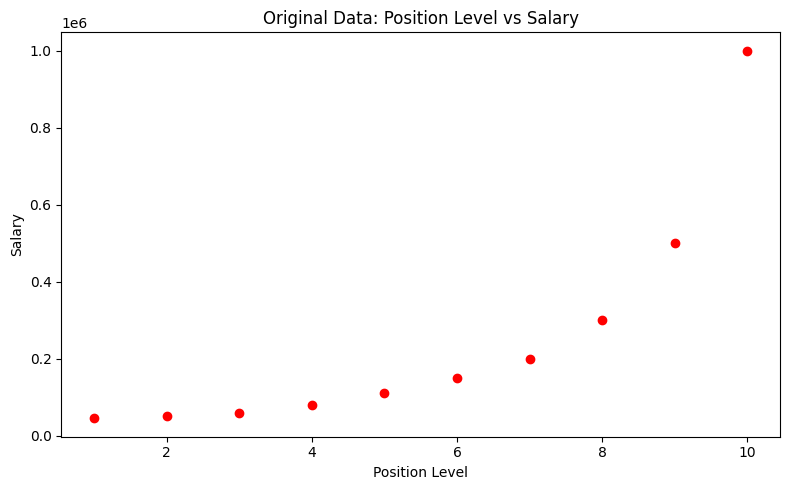

In [13]:
# Scatter plot of the original data (Level vs Salary)
plt.scatter(X, y, color='red')
plt.title('Original Data: Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.tight_layout()
plt.savefig('scatter_original_data.png', dpi=120)
plt.show()

### 4.3 Polynomial Regression Curve

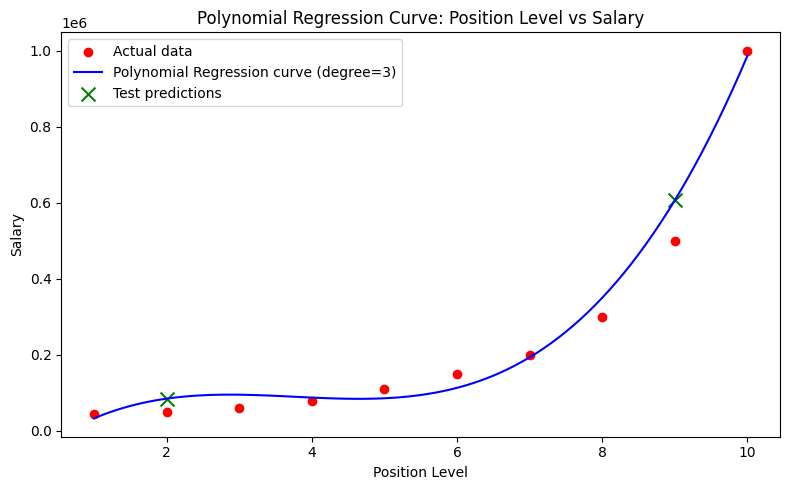

In [14]:
# Polynomial Regression Curve fitted over the original data
X_grid = np.arange(min(X.flatten()), max(X.flatten()) + 0.1, 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)
y_grid_pred = model.predict(X_grid_poly)

plt.scatter(X, y, color='red', label='Actual data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression curve (degree=3)')
plt.scatter(X_test, y_pred, color='green', marker='x', s=100, label='Test predictions')
plt.title('Polynomial Regression Curve: Position Level vs Salary')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.savefig('polynomial_regression_plot.png', dpi=120)
plt.show()

### 4.4 Observations

1. **Fit quality:** The R² score of the model (printed above) indicates the polynomial curve explains a large share of the variance in salary from position level, and the curve visibly follows the steep, non-linear jump at senior levels (Partner → CEO) — something a straight-line (linear) model would badly underestimate.
2. **Error magnitude vs. scale:** The MAE and MSE values are large in absolute terms, but salaries in this dataset range up to 1,000,000; relative to that scale, and given the model is extrapolating from only 8 training points, the errors are reasonable rather than alarming.
3. **Small-sample caution:** Because the dataset has only 10 rows, the 80/20 split leaves just 2 test points, so the metrics above should be read as indicative rather than statistically robust — a different random split could shift MAE/MSE/R² noticeably. The very close fit on training data is also typical of polynomial regression on small datasets and carries some risk of overfitting.


## Task 5: Conclusion

This project applied Polynomial Regression (degree 3) to predict employee salary from position level. The dataset shows salary rising slowly at junior levels and then sharply at senior levels (Partner through CEO), a curve a straight line cannot follow. Fitting a cubic polynomial let the model trace this trend closely, and the evaluation metrics (MAE, MSE, R² ≈ 0.88) confirm a strong fit, though the tiny sample size (10 rows) limits confidence in the test-set numbers.

**Linear vs. Polynomial Regression:** Linear Regression fits one straight line and assumes a constant rate of change. Polynomial Regression fits a curve by adding higher-degree terms of the same feature, letting it bend to follow non-linear trends.

**Advantage here:** Polynomial Regression captures the accelerating salary growth at senior levels, giving far more accurate predictions than a linear model, which would underfit both ends of the position scale.
